In [3]:
import brian2
import matplotlib.pyplot as plt
from brian2 import ms

In [4]:
import brian2.stateupdaters
methods_list = list(brian2.stateupdaters.StateUpdateMethod.stateupdaters.keys())[:-6]
print(methods_list)

['linear', 'exact', 'independent', 'exponential_euler', 'euler', 'rk2', 'rk4', 'milstein', 'heun']


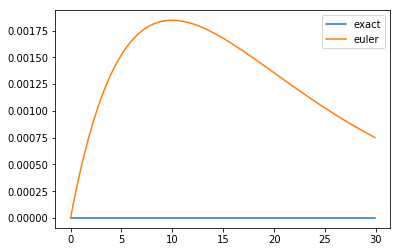

In [5]:
brian2.start_scope()

tau = 10*ms
eqs = "dv/dt=(1-v)/tau : 1"

group_exact = brian2.NeuronGroup(1, eqs, method='exact')
group_euler = brian2.NeuronGroup(1, eqs, method='euler')
monitor_exact = brian2.StateMonitor(group_exact, 'v', record=True)
monitor_euler = brian2.StateMonitor(group_euler, 'v', record=True)
brian2.run(30*ms)
plt.plot(monitor_exact.t/ms, monitor_exact.v[0]-(1-brian2.exp(-monitor_exact.t/tau)), label=monitor_exact.source.method_choice)
plt.plot(monitor_euler.t/ms, monitor_euler.v[0]-(1-brian2.exp(-monitor_euler.t/tau)), label=monitor_euler.source.method_choice)
plt.legend()

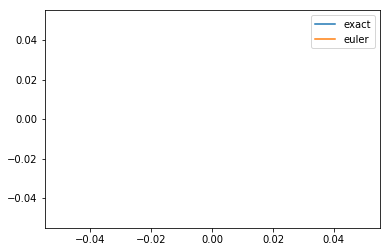

In [7]:
brian2.start_scope()

tau = 10*ms
eqs = "dv/dt=(1-v)/tau : 1"

groups_list = [brian2.NeuronGroup(1, eqs, method=method) for method in ['exact','euler']]#methods_list[:2]]
monitors_list = [brian2.StateMonitor(group, 'v', record=True) for group in groups_list]

brian2.run(30*ms)
for monitor in monitors_list:
    plt.plot(monitor.t/ms, monitor.v[0]-(1-brian2.exp(-monitor.t/tau)), label=monitor.source.method_choice)
plt.legend()

WARNING    The 'independent' state updater is deprecated and might be removed in future versions of Brian. [brian2.stateupdaters.exact.deprecated_independent]
WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
       -4.10782519e-15, -3.99680289e-15, -4.10782519e-15]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
       -4.10782519e-15, -3.99680289e-15, -4.10782519e-15]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
   

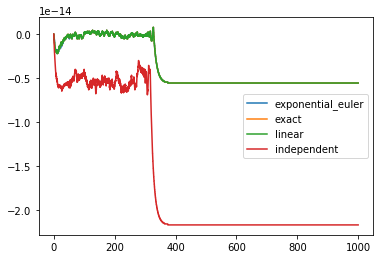

In [26]:
def func(method):
    brian2.start_scope()

    tau = 10*ms
    eqs = """
        dv/dt=(1-v)/tau : 1
        """
    group = brian2.NeuronGroup(1, eqs, method=method)
    monitor = brian2.StateMonitor(group, 'v', record=True)
    brian2.run(1000*ms)

    return monitor.t/ms, monitor.v[0] - (1-brian2.exp(-monitor.t/tau)), method

import multiprocessing
with multiprocessing.Pool(multiprocessing.cpu_count()) as pool:
    for t, v, m in pool.imap_unordered(func, ['linear', 'exact', 'independent', 'exponential_euler']):#methods_list):
        plt.plot(t, v, label=m)
plt.legend()

WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
       -2.16493490e-14, -2.16493490e-14, -2.16493490e-14]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    The 'independent' state updater is deprecated and might be removed in future versions of Brian. [brian2.stateupdaters.exact.deprecated_independent]
WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
       -2.16493490e-14, -2.16493490e-14, -2.16493490e-14]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    "v" is an internal variable of group "neurongroup", but also exists in the run namespace with the value array([ 0.00000000e+00, -5.37764278e-17, -2.63677968e-16, ...,
   

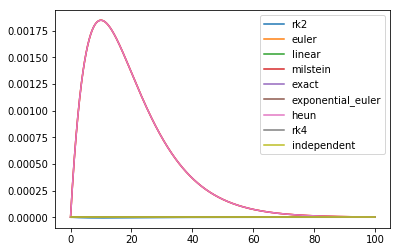

In [28]:
def func(method):
    brian2.start_scope()

    tau = 10*ms
    eqs = """
        dv/dt=(1-v)/tau : 1
        """
    group = brian2.NeuronGroup(1, eqs, method=method)
    monitor = brian2.StateMonitor(group, 'v', record=True)
    brian2.run(100*ms)

    return monitor.t/ms, monitor.v[0] - (1-brian2.exp(-monitor.t/tau)), method

import multiprocessing
with multiprocessing.Pool(multiprocessing.cpu_count()) as pool:
    for t, v, m in pool.imap_unordered(func, methods_list):
        plt.plot(t, v, label=m)
plt.legend()